# Mean median imputation

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('titanic_toy.csv')

In [3]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [6]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

The age columns has 19% of the missing values so it is not good to impute the mean or median value in age.  
lets just impute the fare column which has 5% missing values the imputation will work well on that column.

In [10]:
df['Fare'].mean(), df['Fare'].median()

(np.float64(32.279338297872336), np.float64(14.4542))

In [11]:
df['Mean_inputed'] = df['Fare'].fillna(df['Fare'].mean())
df['Median_inputed'] = df['Fare'].fillna(df['Fare'].median())

In [17]:
df.isnull().sum()

Age               177
Fare               45
Family              0
Survived            0
Mean_inputed        0
Median_inputed      0
dtype: int64

So the Fare column is now imputed with both mean and median.

## Lets check the data has any major changes.

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='Fare', ylabel='Density'>

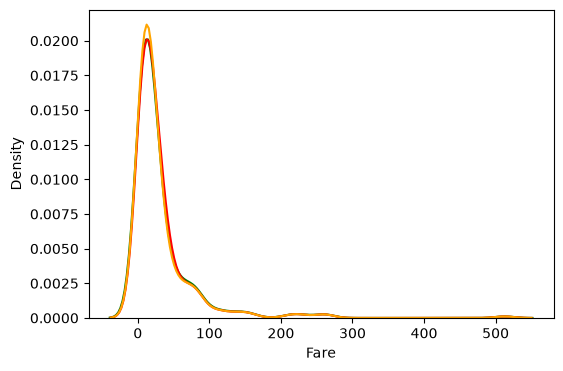

In [59]:
plt.figure(figsize=(6, 4))
sns.kdeplot(df['Fare'], color='green')
sns.kdeplot(df['Mean_inputed'], color='red')
sns.kdeplot(df['Median_inputed'], color='orange')

In [44]:
df['Fare'].mean(), df['Mean_inputed'].mean(), df['Median_inputed'].mean()

(np.float64(32.279338297872336),
 np.float64(32.27933829787234),
 np.float64(31.37907878787879))

In [45]:
df['Fare'].median(), df['Mean_inputed'].median(), df['Median_inputed'].median()

(np.float64(14.4542), np.float64(15.5), np.float64(14.4542))

### The mean imputation has a little impact but the median has niglijible amount of effect on data distribution.

In [62]:
from sklearn.impute import SimpleImputer

In [63]:
si = SimpleImputer(strategy='mean')

In [70]:
a = si.fit_transform(pd.DataFrame(df['Fare']))

<Axes: xlabel='Fare'>

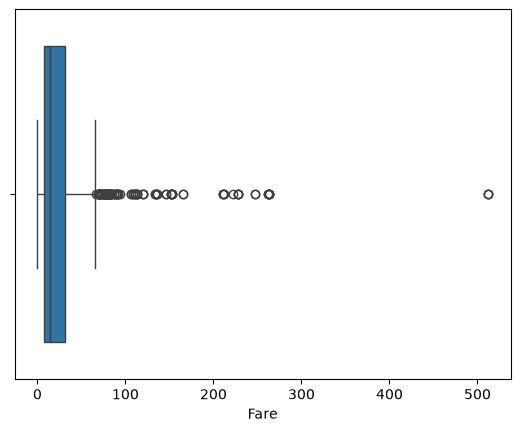

In [74]:
sns.boxplot(data=df, x='Fare')

<Axes: xlabel='Mean_inputed'>

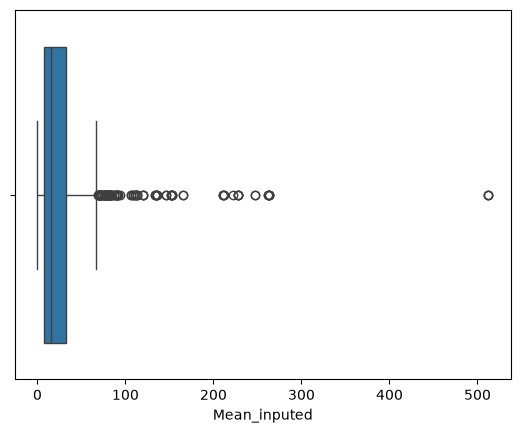

In [75]:
sns.boxplot(data=df, x='Mean_inputed')

<Axes: xlabel='Median_inputed'>

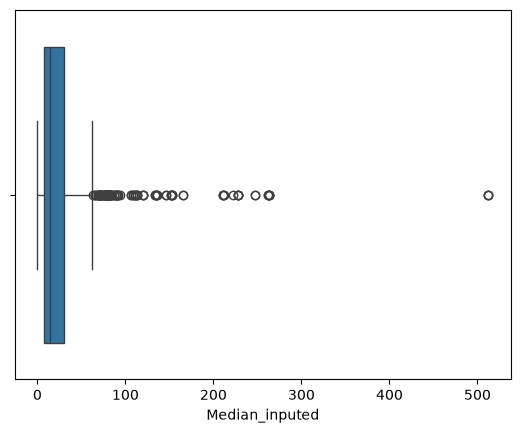

In [76]:
sns.boxplot(data=df, x='Median_inputed')